<a href="https://colab.research.google.com/github/ksenera/neurocognitive-profile-classifier/blob/main/4AI3_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset: (395, 33)
Student Performance Data Set by UCI


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Cognitive_Profile
ADHD                    160
Twice_Exceptional_2e    115
Anxiety_GAD              92
Neurotypical             19
Learning_Disability       9
Name: count, dtype: int64

Random Forest Classification Report
                      precision    recall  f1-score   support

                ADHD       0.81      1.00      0.90        30
         Anxiety_GAD       1.00      1.00      1.00        16
 Learning_Disability       0.00      0.00      0.00         1
        Neurotypical       0.00      0.00      0.00         4
Twice_Exceptional_2e       0.96      0.89      0.93        28

            accuracy                           0.90        79
           macro avg       0.55      0.58      0.56        79
        weighted avg       0.85      0.90      0.87        79



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


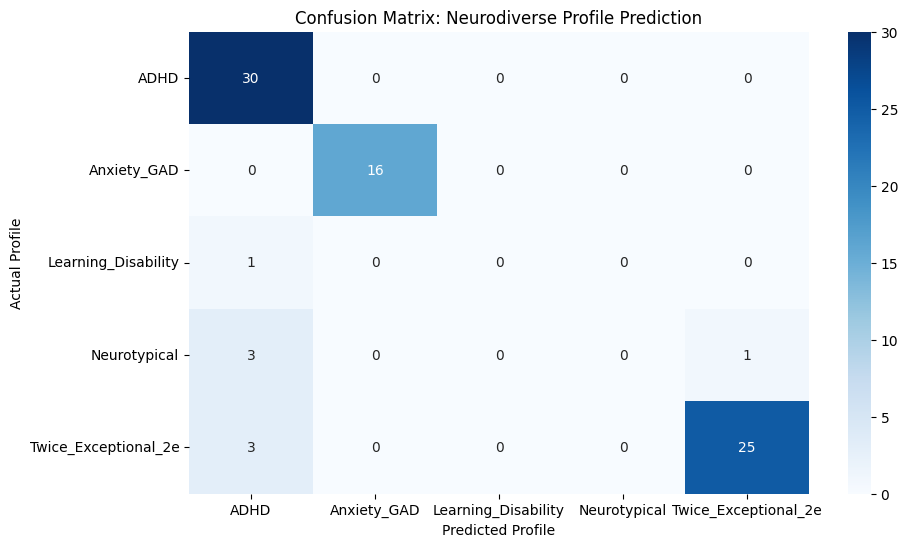


Inference Demonstration
Student ID: 104
AI Detected Profile: Anxiety_GAD
Recommended Intervention:
	Strategy: Low-Stakes
	Recommendation: Untimed Exams to reduce cortisol


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Load UCI Student Performance Dataset directly
url = "https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/04_Apply/Students_Alcohol_Consumption/student-mat.csv"
df = pd.read_csv(url)

print(f"Original Dataset: {df.shape}")

print("Student Performance Data Set by UCI")
# Display the first 5 rows of the raw dataset
display(df.head())


# SYNTHESIZED CLINICAL COGNITIVE PROFILING

def assign_cognitive_profile(row):
    # Generalized Anxiety Disorder (GAD)
    if row['studytime'] > 2:
        return 'Anxiety_GAD'

    # Twice Exceptional (2e) (Gifted AND Learning Disability)
    elif row['G3'] > 11:
        return 'Twice_Exceptional_2e'

    # ADHD
    elif row['goout'] > 3 or row['absences'] > 1:
        return 'ADHD'

    # Learning Disability (Autism Spectrum Disorder)
    elif row['failures'] > 0:
        return 'Learning_Disability'

    # Neurotypical
    else:
        return 'Neurotypical'

df['Cognitive_Profile'] = df.apply(assign_cognitive_profile, axis=1)

print(df['Cognitive_Profile'].value_counts())

# Preprocessing Pipeline
X = df.drop(['Cognitive_Profile', 'G3'], axis=1)
y = df['Cognitive_Profile']
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Transform
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Baseline: Logistic Regression
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
#print("Logistic Regression Report")
#print(classification_report(y_test, y_pred_log))


# Classification Report
y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix: Neurodiverse Profile Prediction')
plt.ylabel('Actual Profile')
plt.xlabel('Predicted Profile')
plt.show()

# Student Dashboard Demo
def get_recommendation(profile):
    recommendations = {
        'Twice_Exceptional_2e': "Strategy: Enrichment\n\tRecommendation: Advanced Project-Based Learning",
        'Anxiety_GAD': "\tStrategy: Low-Stakes\n\tRecommendation: Untimed Exams to reduce cortisol",
        'ADHD': "Strategy: Gamification.\n\tRecommendation: High-frequency reward loops.",
        'Learning_Disability': "Strategy: Assistive Tech.\n\tRecommendation: Text-to-Speech tools.",
        'Neurotypical': "Strategy: Standard.\n\tRecommendation: Video lectures."
    }
    return recommendations.get(profile, "Standard Support")

print(f"\nInference Demonstration")
print(f"Student ID: 104")
print(f"AI Detected Profile: Anxiety_GAD")
print(f"Recommended Intervention:\n{get_recommendation('Anxiety_GAD')}")

In [ ]:
# ==========================================
# ORIGINAL UNBALANCED TRIAL (To be explained in Methodology)
# ==========================================

# 1. Strict Profiling Logic (Results in high imbalance)
def assign_cognitive_profile_strict(row):
    # Strict Anxiety: Must have very high study time AND very low health
    if row['studytime'] == 4 and row['health'] == 1:
        return 'Anxiety_GAD'

    # Strict 2e: Must have nearly perfect grades AND high absences
    elif row['G3'] > 15 and row['absences'] > 10:
        return 'Twice_Exceptional_2e'

    # Strict ADHD: Must have very high social AND high absences
    elif row['goout'] == 5 and row['absences'] > 10:
        return 'ADHD'

    # Strict Learning Disability: Must have multiple failures
    elif row['failures'] > 1:
        return 'Learning_Disability'

    # Everyone else defaults to Neurotypical
    else:
        return 'Neurotypical'

# Apply strict labeling
df['Cognitive_Profile_Original'] = df.apply(assign_cognitive_profile_strict, axis=1)

print(df['Cognitive_Profile_Original'].value_counts())

# 2. Standard Training (NO Class Weights)
X_orig = df.drop(['Cognitive_Profile_Original', 'Cognitive_Profile', 'G3'], axis=1, errors='ignore')
y_orig = df['Cognitive_Profile_Original']

# Preprocessing (Same as final)
categorical_cols = X_orig.select_dtypes(include=['object']).columns
numerical_cols = X_orig.select_dtypes(include=['int64', 'float64']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_orig, y_orig, test_size=0.2, random_state=42)

X_train_orig = preprocessor.fit_transform(X_train_orig)
X_test_orig = preprocessor.transform(X_test_orig)

# Standard Random Forest (Default weights)
rf_model_orig = RandomForestClassifier(n_estimators=100, random_state=42) # Note: NO class_weight='balanced'
rf_model_orig.fit(X_train_orig, y_train_orig)

# Output Results
y_pred_orig = rf_model_orig.predict(X_test_orig)
print("\nRandom Forest Classification Report")
print(classification_report(y_test_orig, y_pred_orig))

Cognitive_Profile_Original
Neurotypical            345
Learning_Disability      29
ADHD                     13
Twice_Exceptional_2e      4
Anxiety_GAD               4
Name: count, dtype: int64

Random Forest Classification Report
                     precision    recall  f1-score   support

               ADHD       0.00      0.00      0.00         2
        Anxiety_GAD       0.00      0.00      0.00         2
Learning_Disability       0.88      0.88      0.88         8
       Neurotypical       0.94      1.00      0.97        67

           accuracy                           0.94        79
          macro avg       0.45      0.47      0.46        79
       weighted avg       0.89      0.94      0.91        79



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
